--- Top 20 Features with Missing Values ---
price     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  hotwaterheating  airconditioning  parking  prefarea  furnishingstatus
11410000  7420  4         1          2        yes       yes        yes       no               yes              2        no        furnished           1
12215000  7500  4         2          2        yes       no         yes       no               yes              3        yes       furnished           1
12250000  8960  4         4          4        yes       no         no        no               yes              3        no        furnished           1
          9960  3         2          2        yes       no         yes       no               no               2        yes       semi-furnished      1
13300000  7420  4         2          3        yes       no         no        no               yes              2        yes       furnished           1
Name: count, dtype: int64
                  Total

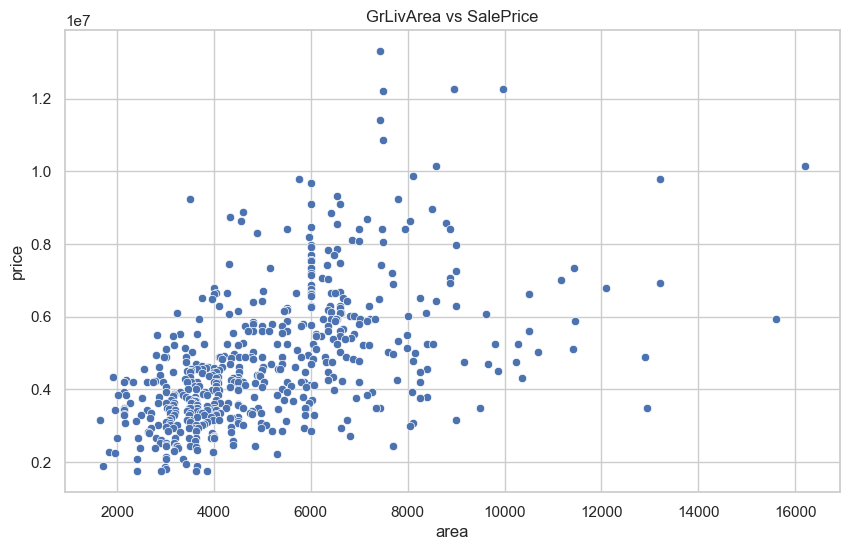

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis

# Set Visualization Style
sns.set(style="whitegrid")

# Reading The Data
data = pd.read_csv("Housing.csv")
df = pd.DataFrame(data)
print("--- Top 20 Features with Missing Values ---")
print(df.head().value_counts())
total_missing = df.isnull().sum().sort_values(ascending=False)
percent_missing = (df.isnull().sum() / df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total_missing, percent_missing], axis=1, keys=['Total', 'Percent'])
print(missing_data.head(20))

# As the data is clean, we can proceed without handling missing values
# Outlier Detection and Removal
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df)
plt.title('GrLivArea vs SalePrice')
plt.show()




Skewness of Sale Price: -0.18849484702724256
Kurtosis of Sale Price: 0.31250670763371247


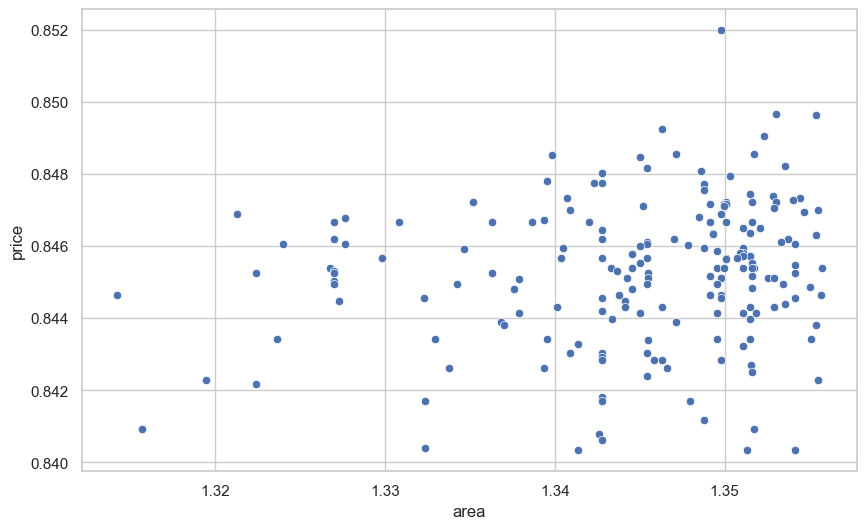

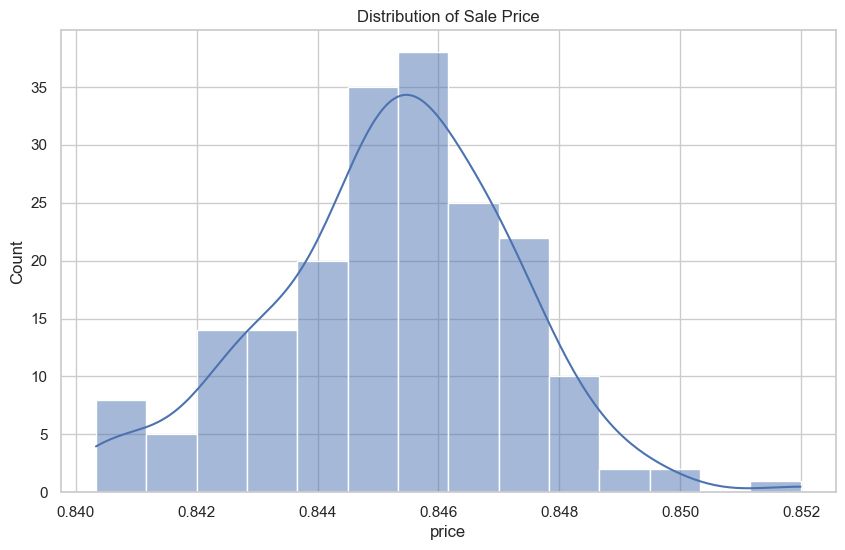

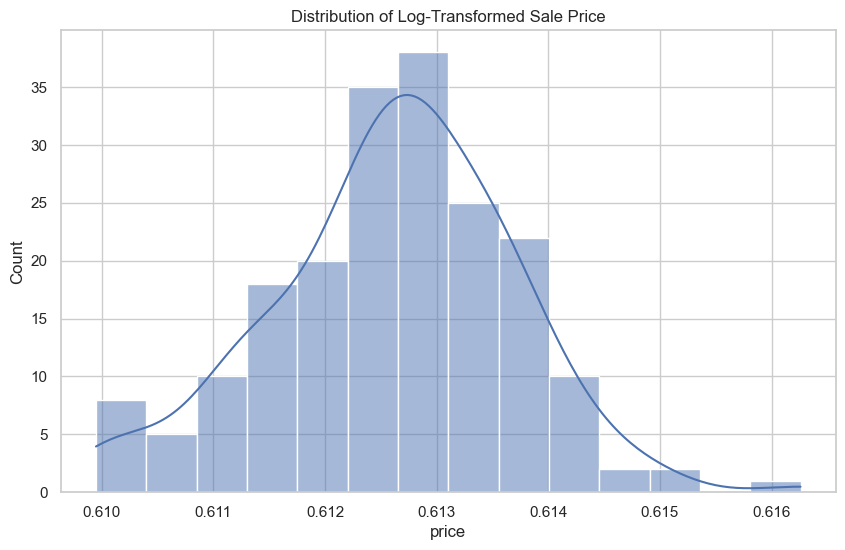

In [18]:
# Cleaning the data
df = df[df['area'] < 4000]  # Removing outliers where area is greater than 4000
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df)

# Target Variable Analysis
# Univariate Analysis
sale_price_skew = skew(df['price'])
sale_price_kurtosis = kurtosis(df['price'])
print(f"Skewness of Sale Price: {sale_price_skew}")
print(f"Kurtosis of Sale Price: {sale_price_kurtosis}")

# Plotting the distribution of Sale Price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Sale Price')
plt.show()

# Transformation to reduce skewness
df['price'] = np.log1p(df['price'])
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Log-Transformed Sale Price')
plt.show()




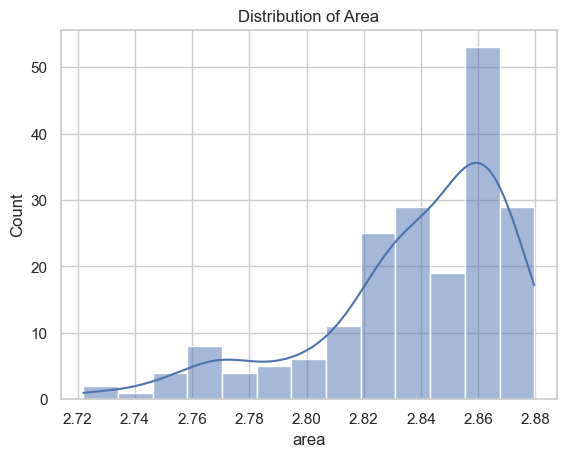

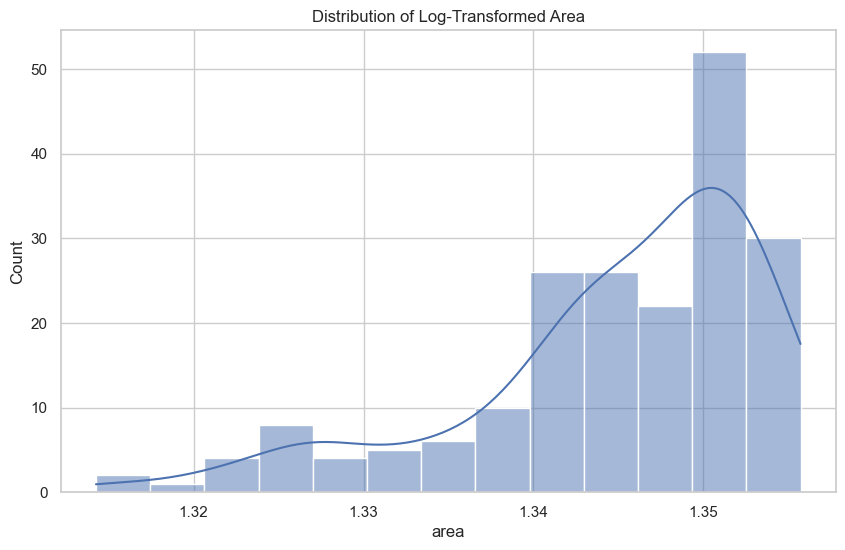

In [17]:
# Tramsformation distribution of area
sns.histplot(df['area'], kde=True)
plt.title('Distribution of Area')   
plt.show()

# Area negative skewness transformation
df['area'] = np.log1p(df['area'])
plt.figure(figsize=(10, 6))
sns.histplot(df['area'], kde=True)
plt.title('Distribution of Log-Transformed Area')
plt.show()

In [5]:
# Data preprocessing

# Label Encoding Categorical Features
from sklearn.preprocessing import LabelEncoder

df_label = df.copy()
le = LabelEncoder()
df_label['guestroom'] = le.fit_transform(df_label['guestroom'])
df_label['basement'] = le.fit_transform(df_label['basement'])
df_label['hotwaterheating'] = le.fit_transform(df_label['hotwaterheating'])
df_label['airconditioning'] = le.fit_transform(df_label['airconditioning'])
df_label['prefarea'] = le.fit_transform(df_label['prefarea'])
df_label['mainroad'] = le.fit_transform(df_label['mainroad'])

# One-Hot Encoding Categorical Features
df_encoded = pd.get_dummies(df_label, columns=['furnishingstatus'], drop_first=True, dtype=int)
# Verifying the transformations
print(df_encoded.head())


      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                                0                             0  
1                       

In [8]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Splitting the data
X=df_encoded.drop('price', axis=1)
y=df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Training the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
# Making predictions
y_pred = lr_model.predict(X_test)
# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Testing the model
test_data = {
    'area': [2500],
    'bedrooms': [4],
    'bathrooms': [3],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [0],
    'basement': [1],
    'hotwaterheating': [0],
    'airconditioning': [1],
    'parking': [2],
    'prefarea': [1],
    'furnishingstatus_semi-furnished': [0],
    'furnishingstatus_unfurnished': [1]
}
test_df = pd.DataFrame(test_data)
predicted_price = lr_model.predict(test_df)
print(f"Predicted Log-Transformed Price: {predicted_price[0]}")

Mean Squared Error: 1754318687330.6638
R-squared: 0.6529242642153184
Predicted Log-Transformed Price: 7470883.913112269
